In [2]:
### ARTS as the line-by-line code
import os
# set global variables BEFORE importing ARTS
os.environ['ARTS_DATA_PATH'] = '../arts-cat-data-2.6.14:../arts-xml-data-2.6.14'

import pyarts
from pyarts.arts import convert
# the fluxsim module
import FluxSimulator as fsm
import seaborn as sns

from pyrte_rrtmgp.rrtmgp.data_files import (
    CloudOpticsFiles,
    GasOpticsFiles,
)

from pyrte_rrtmgp.examples import (
    compute_RCE_clouds,
    compute_RCE_profiles,
    load_example_file,
    ALLSKY_EXAMPLES,
)
from pyrte_rrtmgp import rte
from pyrte_rrtmgp.rrtmgp import GasOptics, CloudOptics

# helper packages
import numpy as np
import xarray as xr
from scipy.constants import speed_of_light as c
import matplotlib.pyplot as plt

import typhon
import typhon.constants as tpc
import pandas as pd

plt.style.use('figsettings.mplstyle')


In [6]:
rte_sw = xr.open_dataset('/home/pczarnec/.cache/pyrte_rrtmgp/rrtmgp-data-1.9/rrtmgp-clouds-sw-bnd.nc').compute()
rte_lw = xr.open_dataset('/home/pczarnec/.cache/pyrte_rrtmgp/rrtmgp-data-1.9/rrtmgp-clouds-lw-bnd.nc').compute()

ddq_sw = xr.open_dataset('/homedata/pczarnec/ddq-implementation-sprint/DDQ configurations/DDQ_SW.h5', engine = "netcdf4").compute()
ddq_lw = xr.open_dataset('/homedata/pczarnec/ddq-implementation-sprint/DDQ configurations/DDQ_LW.h5', engine = "netcdf4").compute()

getfattr: /homedata/pczarnec/ddq-implementation-sprint/DDQ: No such file or directory
getfattr: configurations/DDQ_SW.h5: No such file or directory
getfattr: /homedata/pczarnec/ddq-implementation-sprint/DDQ: No such file or directory
getfattr: configurations/DDQ_LW.h5: No such file or directory


In [7]:
# For each S, find the band index where limits[:,0] <= S <= limits[:,1]
def find_band(s, limits):
    for i, (lo, hi) in enumerate(limits):
        if lo <= s <= hi:
            return i
    return -1  # not found / out of range


# Get band limits as a numpy array, shape (nband, pair)
limits = rte_sw.bnd_limits_wavenumber.values  # shape (14, 2)

# S values to classify
s_vals = ddq_sw.S.values  # shape (64,)

band_idx = np.array([find_band(s, limits) for s in s_vals])

# Attach as a new coordinate on ddq_sw
ddq_sw = ddq_sw.assign_coords(band=("S", band_idx))

print(ddq_sw.band.values)

limits = rte_lw.bnd_limits_wavenumber.values
s_vals = ddq_lw.S.values
band_idx = np.array([find_band(s, limits) for s in s_vals])

ddq_lw = ddq_lw.assign_coords(band = ("S", band_idx))

print(ddq_lw.band.values)


[ 0  0  1  2  2  2  2  2  3  4  5  6  6  6  6  6  6  6  8  8  8  8  8  8
  8  8  8  8  8  9  9  9  9  9 10 10 10 10 10 10 10 10 11 11 11 12 12 12
 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13]
[ 0  0  0  0  0  0  1  1  1  1  1  1  2  2  2  2  2  2  3  3  3  3  3  3
  3  3  3  3  3  3  4  4  4  4  4  4  5  5  5  5  5  6  6  6  6  6  6  7
  7  8  8  8  8  8  8  8  9  9 10 10 11 11 12 15]


In [8]:
rte_sw_ddq = rte_sw.isel(nband = ddq_sw.band.values)
rte_lw_ddq = rte_lw.isel(nband = ddq_lw.band.values)

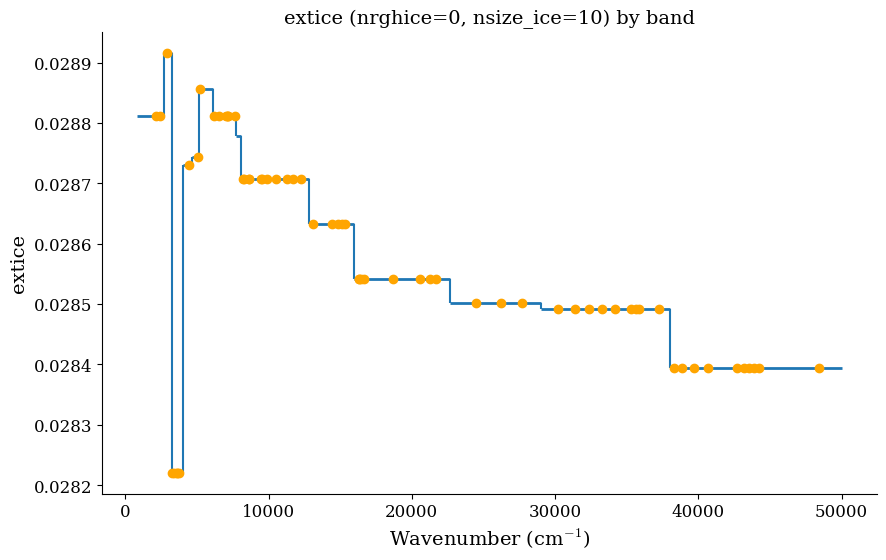

In [9]:
limits = rte_sw.bnd_limits_wavenumber.values  # (nband, 2)

# pick which ice-roughness and size index to plot
irghice = 0
isize = 10

ext_vals = rte_sw.extice.isel(nrghice=irghice, nsize_ice=isize).values  # (nband,)

fig, ax = plt.subplots(figsize=(10, 6))

for i, (lo, hi) in enumerate(limits):
    ax.hlines(ext_vals[i], lo, hi, color="C0", linewidth=2)
    # optional: vertical connector lines between bands
    if i > 0:
        ax.vlines(lo, ext_vals[i-1], ext_vals[i])

ax.plot(ddq_sw.S.data, rte_sw_ddq.isel(nrghice=irghice, nsize_ice=isize).extice.data, 'o', color = 'orange')
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("extice")
ax.set_title(f"extice (nrghice={irghice}, nsize_ice={isize}) by band")
plt.show()

In [11]:
rte_sw_ddq = rte_sw_ddq.assign({'bnd_limits_wavenumber': (("nband", "pair"), np.array([[wn, wn] for wn in ddq_sw.S.data]))})
rte_lw_ddq = rte_lw_ddq.assign({'bnd_limits_wavenumber': (("nband", "pair"), np.array([[wn, wn] for wn in ddq_lw.S.data]))})

In [12]:
rte_sw_ddq.to_netcdf('Cloud Optics Data/rrtmgp-clouds-sw-ddq.nc')
rte_lw_ddq.to_netcdf('Cloud Optics Data/rrtmgp-clouds-lw-ddq.nc')